# Final figure — quantitative panels D–F

Self-contained generator for the three quantitative panels of the composite figure
(P12 · MSIT · LVF · θ), matching the final panel arrangement:

- **Panel D** — error shrinkage from $g(x)$, ID vs OOD (conflict + stim-context shifts)
- **Panel E** — residual growth vs horizon for increasing context length
- **Panel F** — state size vs residual size (across leads + LVF channel subsets)

Runs from the cached sessions in `cache/` (no raw .mat files needed). Outputs are saved
to `figures/final_panel{D,E,F}_*.png/pdf` and `results/final_panel*.csv`.
Metric: median per-token residual RMS across channels, in baseline-SD units (z); lower = better.

In [1]:
# ---------- Setup: config + cached sessions ----------
import io
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, hilbert
from IPython.display import Image as IPyImage

HERE = Path.cwd()
CACHE_DIR = HERE / "cache"
FIG_DIR = HERE / "plots"
RESULTS_DIR = HERE / "results"
for d in (FIG_DIR, RESULTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

EPOCH_MS = (-500, 1500)
BANDS = {"theta": (4, 8)}
PRIMARY_BAND = "theta"
TOKEN_STRIDE_MS = 20
CAUSAL_WINDOW_MS = 40
SPLIT_FRACS = (0.6, 0.2, 0.2)
RANDOM_SEED = 0
POC_LEAD = "LVF"
MIN_CH = 5

COLOR_LINEAR = "#1f4ea1"
COLOR_RESIDUAL = "#c1272d"
COLOR_ID = "#7f9fbf"
COLOR_OOD = "#bf8f7f"

def load_cached(name):
    f = np.load(CACHE_DIR / f"{name}.npz", allow_pickle=False)
    return {"data": f["data"], "time": f["time"], "fs": float(f["fs"]),
            "trials": pd.read_csv(io.StringIO(str(f["trials_csv"]))),
            "channels": pd.read_csv(io.StringIO(str(f["channels_csv"]))),
            "stim_flag": float(f["stim_flag"])}

sess = load_cached("P12_NoStim2")        # NS1: no-stim session (train + ID test)
sess_stim = load_cached("P12_Stim1")     # NS2: non-stim trials in stim blocks (OOD)
for s_ in (sess, sess_stim):
    s_["channels"]["lead"] = s_["channels"]["pair_name"].str.extract(r"^([A-Za-z]+)")
print(f"NoStim2: {sess['data'].shape}  |  Stim1: {sess_stim['data'].shape}  (trials, channels, samples)")

NoStim2: (127, 151, 6000)  |  Stim1: (383, 152, 6000)  (trials, channels, samples)


In [2]:
# ---------- Preprocessing: theta tokens, splits, conflict axis ----------
def band_power(data, fs, band):
    lo, hi = BANDS[band]
    sos = butter(4, [lo, hi], btype="bandpass", fs=fs, output="sos")
    filt = sosfiltfilt(sos, data, axis=-1)
    return np.abs(hilbert(filt, axis=-1)).astype(np.float32) ** 2

def tokenize(power, time):
    """Causal tokens: mean power over [t-40ms, t], 20-ms stride, t in [40, 1500] ms."""
    t_ms = time * 1000.0
    token_t = np.arange(CAUSAL_WINDOW_MS, EPOCH_MS[1] + 1, TOKEN_STRIDE_MS, dtype=float)
    toks = [power[:, :, (t_ms > t - CAUSAL_WINDOW_MS) & (t_ms <= t)].mean(axis=-1) for t in token_t]
    tokens = np.stack(toks, axis=1)
    base_m = (t_ms >= EPOCH_MS[0]) & (t_ms < 0)
    baseline = power[:, :, base_m].mean(axis=-1)
    return tokens, baseline, token_t

def trial_split(n_trials, fracs=SPLIT_FRACS, seed=RANDOM_SEED):
    rng_ = np.random.default_rng(seed)
    order = rng_.permutation(n_trials)
    n_tr = int(round(fracs[0] * n_trials)); n_va = int(round(fracs[1] * n_trials))
    return order[:n_tr], order[n_tr:n_tr + n_va], order[n_tr + n_va:]

clean_idx = np.flatnonzero(~sess["channels"]["ictal"].to_numpy())
pw = band_power(sess["data"][:, clean_idx, :], sess["fs"], PRIMARY_BAND)
tokens, baseline, token_t = tokenize(pw, sess["time"])
del pw
_pre = HERE / "cache" / "brain" / "preprocessed"
_pre.mkdir(parents=True, exist_ok=True)
np.savez_compressed(_pre / "P12_NoStim2_theta_tokens.npz", tokens=tokens, baseline=baseline,
                    token_t=token_t, clean_idx=clean_idx)

lead_clean = sess["channels"]["lead"].to_numpy()[clean_idx]
names_clean = sess["channels"]["pair_name"].to_numpy()[clean_idx]
region_mask_in_clean = lead_clean == POC_LEAD
tok_r = tokens[:, :, region_mask_in_clean]
base_r = baseline[:, region_mask_in_clean]

tr, va, te = trial_split(tokens.shape[0])
mu = base_r[tr].mean(axis=0); sd = base_r[tr].std(axis=0) + 1e-12
z_r = (tok_r - mu[None, None, :]) / sd[None, None, :]      # NS1-train frozen normalization

# conflict axis: fit on LOW-conflict trials only, HIGH-conflict fully held out (OOD)
conf = sess["trials"]["Conflict"].to_numpy()
low_trials = np.flatnonzero(conf <= 1)
high_trials = np.flatnonzero(conf >= 2)
tr_lo, va_lo, te_lo = trial_split(len(low_trials))
tr_lo, va_lo, te_lo = low_trials[tr_lo], low_trials[va_lo], low_trials[te_lo]
mu_lo = base_r[tr_lo].mean(axis=0); sd_lo = base_r[tr_lo].std(axis=0) + 1e-12
z_c = (tok_r - mu_lo[None, None, :]) / sd_lo[None, None, :]

print(f"clean channels: {len(clean_idx)}  |  {POC_LEAD}: {int(region_mask_in_clean.sum())}  |  "
      f"tokens: {tokens.shape}  |  split: {len(tr)}/{len(va)}/{len(te)}  |  "
      f"conflict low/high: {len(low_trials)}/{len(high_trials)}")

clean channels: 114  |  LVF: 15  |  tokens: (127, 74, 114)  |  split: 76/25/26  |  conflict low/high: 64/63


In [3]:
# ---------- Models & metrics ----------
import torch
import torch.nn as tnn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def make_pairs(z, h_steps):
    X = z[:, :-h_steps, :].reshape(-1, z.shape[-1])
    Y = z[:, h_steps:, :].reshape(-1, z.shape[-1])
    return X, Y

def make_pairs_ctx(z, h_steps, k_ctx):
    """Context-stacked pairs. X: (pairs, ch*k_ctx) with most recent token first."""
    T = z.shape[1]
    Xs = [z[:, k_ctx - 1 - j:T - h_steps - j, :] for j in range(k_ctx)]
    X = np.concatenate(Xs, axis=-1).reshape(-1, z.shape[-1] * k_ctx)
    Y = z[:, k_ctx - 1 + h_steps:, :].reshape(-1, z.shape[-1])
    return X, Y

def pop_r2(Y, Yhat):
    return 1.0 - ((Y - Yhat) ** 2).sum() / ((Y - Y.mean(axis=0)) ** 2).sum()

def resid_norms(Y, P):
    """Per-token residual RMS across channels (z units)."""
    return np.sqrt(((Y - P) ** 2).mean(axis=1))

def fit_ridge(Xtr, Ytr, Xva, Yva, lambdas=(1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0)):
    Xa = np.hstack([Xtr, np.ones((len(Xtr), 1))])
    XtX, XtY = Xa.T @ Xa, Xa.T @ Ytr
    eye = np.eye(Xa.shape[1]); eye[-1, -1] = 0
    best = None
    for lam in lambdas:
        W = np.linalg.solve(XtX + lam * eye, XtY)
        r2 = pop_r2(Yva, np.hstack([Xva, np.ones((len(Xva), 1))]) @ W)
        if best is None or r2 > best[1]:
            best = (W, r2, lam)
    W, _, lam = best
    return W[:-1].T, W[-1], lam

def ridge_predict(A, b, X):
    return X @ A.T + b

class ResidualMLP(tnn.Module):
    def __init__(self, n):
        super().__init__()
        h = min(32, 2 * n)
        self.net = tnn.Sequential(tnn.Linear(n, h), tnn.ReLU(), tnn.Linear(h, n))
    def forward(self, x):
        return self.net(x)

def fit_residual_mlp(Xtr, Rtr, Xva, Rva, epochs=500, patience=25, seed=RANDOM_SEED):
    torch.manual_seed(seed)
    model = ResidualMLP(Xtr.shape[1]).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    xt, rt = (torch.as_tensor(a, dtype=torch.float32, device=DEVICE) for a in (Xtr, Rtr))
    xv, rv = (torch.as_tensor(a, dtype=torch.float32, device=DEVICE) for a in (Xva, Rva))
    best_state, best_val, bad = None, np.inf, 0
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        loss = tnn.functional.mse_loss(model(xt), rt)
        loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            val = tnn.functional.mse_loss(model(xv), rv).item()
        if val < best_val - 1e-6:
            best_val, bad = val, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                break
    model.load_state_dict(best_state)
    model.eval()
    return model

def mlp_predict(model, X):
    with torch.no_grad():
        return model(torch.as_tensor(X, dtype=torch.float32, device=DEVICE)).cpu().numpy()

print(f"models ready (device={DEVICE})")

models ready (device=cuda)


In [4]:
# ---------- Frozen NS1 models per horizon + stim-context OOD state ----------
# Frozen LVF models (ridge + residual MLP) fit on NS1 train trials only.
models_at_h = {}
for h_ms in [20, 40, 100, 200]:
    hs_ = h_ms // TOKEN_STRIDE_MS
    Xt_, Yt_ = make_pairs(z_r[tr], hs_)
    Xv_, Yv_ = make_pairs(z_r[va], hs_)
    A_h, b_h, _ = fit_ridge(Xt_, Yt_, Xv_, Yv_)
    g_h = fit_residual_mlp(Xt_, Yt_ - ridge_predict(A_h, b_h, Xt_),
                           Xv_, Yv_ - ridge_predict(A_h, b_h, Xv_))
    models_at_h[h_ms] = (A_h, b_h, g_h)
    print(f"frozen NS1 model fit at Δ={h_ms} ms")

# OOD state: NS2 = non-stimulated trials in the Stim1 session, SAME LVF channels by
# name, normalized with the FROZEN NS1-train baseline stats.
poc_pairs = names_clean[region_mask_in_clean]
stim_names = pd.Index(sess_stim["channels"]["pair_name"])
stim_cols = stim_names.get_indexer(poc_pairs)
assert (stim_cols >= 0).all(), "LVF pairs missing in Stim1 montage"

ns2_mask = sess_stim["trials"]["Stimulation"].to_numpy() == 0
d_ood = sess_stim["data"][ns2_mask][:, stim_cols, :]
good_ood = ~np.isnan(d_ood).any(axis=(1, 2))
pw_ood = band_power(d_ood[good_ood], sess_stim["fs"], PRIMARY_BAND)
tok_ood_r, _, _ = tokenize(pw_ood, sess_stim["time"])
z_ood = (tok_ood_r - mu[None, None, :]) / sd[None, None, :]
del d_ood, pw_ood
print(f"OOD (NS2) trials: {int(good_ood.sum())} ({int((~good_ood).sum())} NaN dropped)  |  z_ood: {z_ood.shape}")

# channel-name matching of the FULL clean montage (needed for Panel F per-lead view)
pos_in_stim = stim_names.get_indexer(names_clean)
matched = pos_in_stim >= 0
print(f"clean channels matched in Stim1 montage: {int(matched.sum())}/{len(names_clean)}")

frozen NS1 model fit at Δ=20 ms
frozen NS1 model fit at Δ=40 ms


frozen NS1 model fit at Δ=100 ms
frozen NS1 model fit at Δ=200 ms


OOD (NS2) trials: 269 (0 NaN dropped)  |  z_ood: (269, 74, 15)
clean channels matched in Stim1 montage: 112/114


split                        ID     OOD
axis         horizon_ms                
conflict     20         -0.0002 -0.0076
             40         -0.0006 -0.0036
             100        -0.0236 -0.0057
             200        -0.0328 -0.0130
stim-context 20         -0.0040 -0.0060
             40         -0.0053 -0.0055
             100        -0.0123  0.0103
             200        -0.0160  0.0586

saved -> /home/dev/controller/code/figs/figure_brain/empirical/plots/final_panelD_error_shrinkage_P12_LVF_theta.png


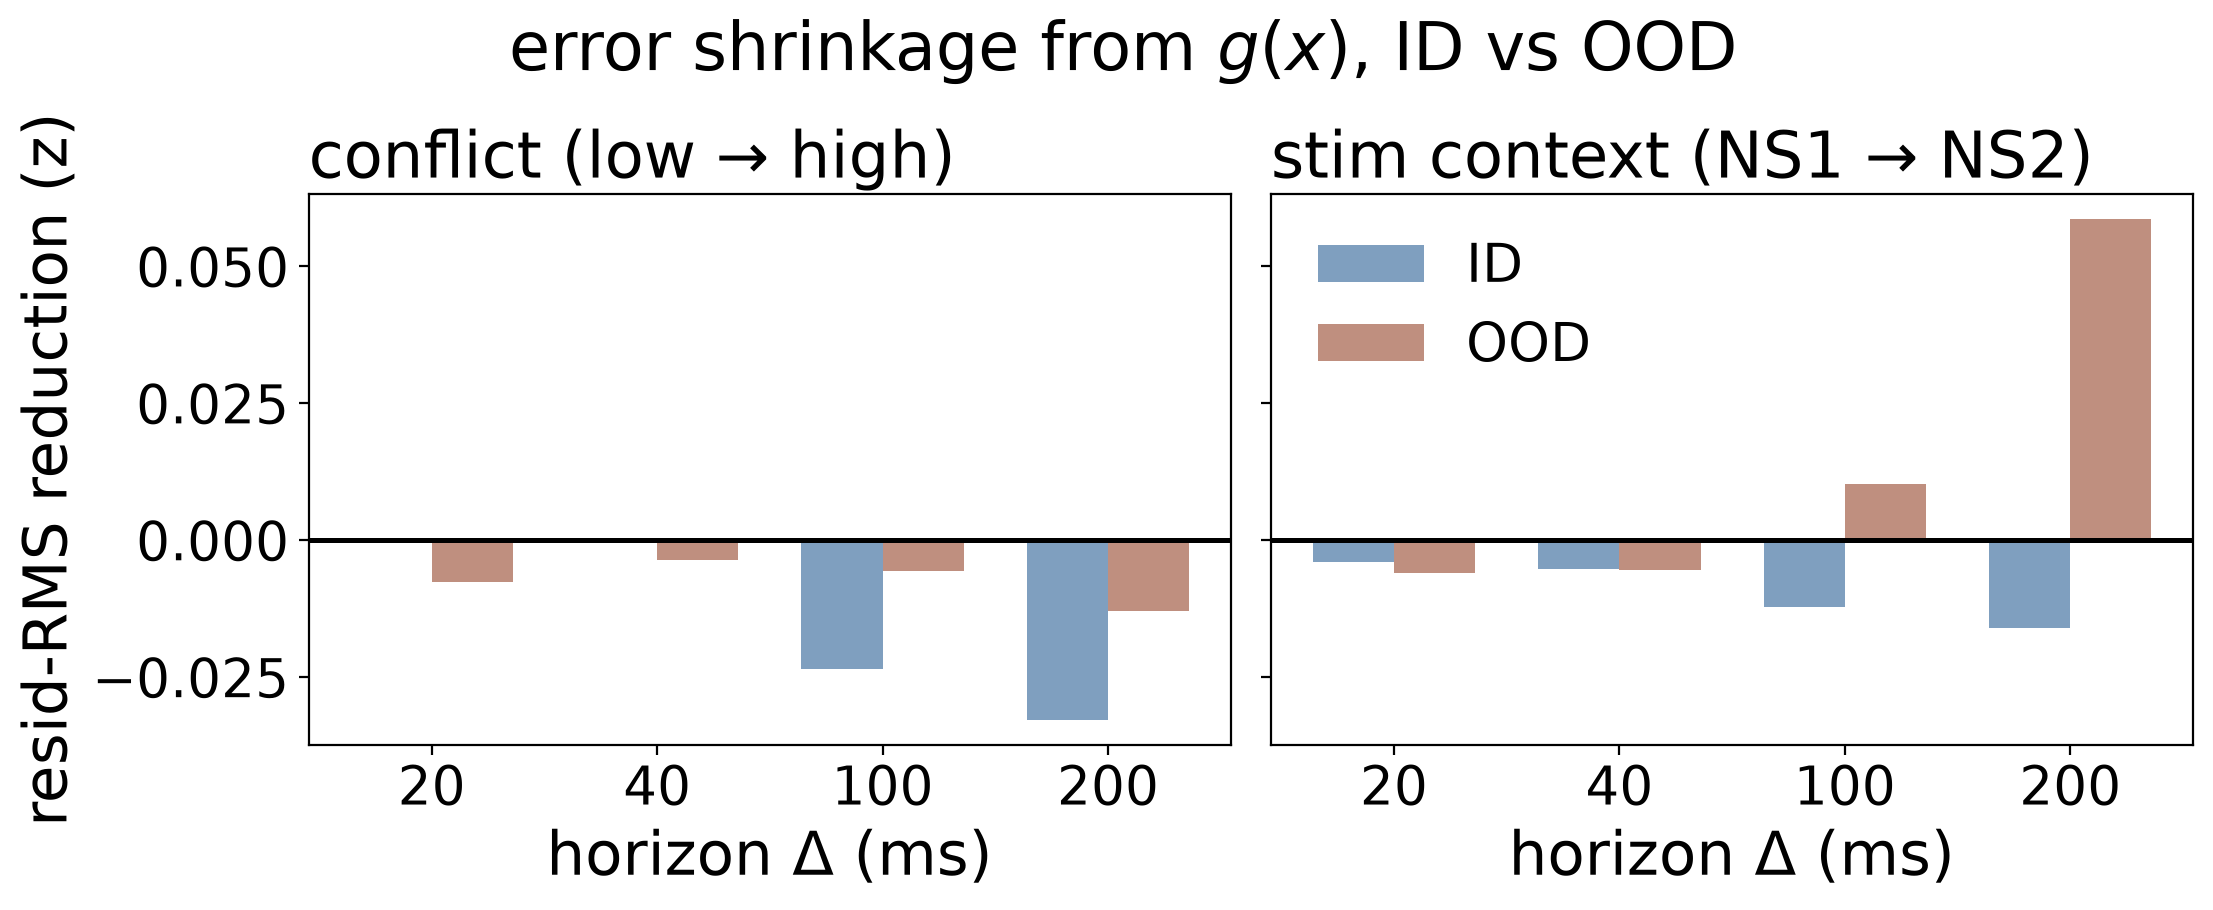

In [5]:
# ---------- Panel D: error shrinkage from g(x), ID vs OOD ----------
# Reduction in median per-token residual RMS contributed by the learned residual:
#   reduction = median RMS(Ax+b) - median RMS(Ax+b+g(x));  positive = smaller errors.
rows_D = []
# stim-block context axis: frozen NS1 models
for h_ms, (A_h, b_h, g_h) in sorted(models_at_h.items()):
    hs_ = h_ms // TOKEN_STRIDE_MS
    for split, zz in [("ID", z_r[te]), ("OOD", z_ood)]:
        Xs_, Ys_ = make_pairs(zz, hs_)
        p_l = ridge_predict(A_h, b_h, Xs_)
        m_lin = float(np.median(resid_norms(Ys_, p_l)))
        m_res = float(np.median(resid_norms(Ys_, p_l + mlp_predict(g_h, Xs_))))
        rows_D.append(dict(axis="stim-context", horizon_ms=h_ms, split=split,
                           med_lin=m_lin, med_res=m_res, reduction=m_lin - m_res))
# conflict axis: frozen low-conflict models (refit per horizon)
for h_ms in [20, 40, 100, 200]:
    hs_ = h_ms // TOKEN_STRIDE_MS
    Xt_, Yt_ = make_pairs(z_c[tr_lo], hs_)
    Xv_, Yv_ = make_pairs(z_c[va_lo], hs_)
    A_D, b_D, _ = fit_ridge(Xt_, Yt_, Xv_, Yv_)
    g_D = fit_residual_mlp(Xt_, Yt_ - ridge_predict(A_D, b_D, Xt_),
                           Xv_, Yv_ - ridge_predict(A_D, b_D, Xv_))
    for split, idxs in [("ID", te_lo), ("OOD", high_trials)]:
        Xs_, Ys_ = make_pairs(z_c[idxs], hs_)
        p_l = ridge_predict(A_D, b_D, Xs_)
        m_lin = float(np.median(resid_norms(Ys_, p_l)))
        m_res = float(np.median(resid_norms(Ys_, p_l + mlp_predict(g_D, Xs_))))
        rows_D.append(dict(axis="conflict", horizon_ms=h_ms, split=split,
                           med_lin=m_lin, med_res=m_res, reduction=m_lin - m_res))
panelD = pd.DataFrame(rows_D)
panelD.to_csv(RESULTS_DIR / "final_panelD_error_shrinkage_LVF_theta.csv", index=False)
display(panelD.pivot(index=["axis", "horizon_ms"], columns="split", values="reduction").round(4))

fig, axes_D = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
for ax_D, axis_name, ttl in zip(axes_D, ["conflict", "stim-context"],
                                ["conflict (low → high)", "stim context (NS1 → NS2)"]):
    gtab = panelD[panelD.axis == axis_name].pivot(index="horizon_ms", columns="split",
                                                  values="reduction").sort_index()
    xD = np.arange(len(gtab)); wD = 0.36
    ax_D.bar(xD - wD/2, gtab["ID"], wD, color=COLOR_ID, label="ID")
    ax_D.bar(xD + wD/2, gtab["OOD"], wD, color=COLOR_OOD, label="OOD")
    ax_D.axhline(0, color="k", lw=1.8)
    ax_D.set_xticks(xD, [f"{h}" for h in gtab.index], fontsize=19)
    ax_D.set_xlabel("horizon $\\Delta$ (ms)", fontsize=22)
    ax_D.set_title(ttl, loc="left", fontsize=23)
    ax_D.tick_params(labelsize=19)
axes_D[0].set_ylabel("resid-RMS reduction (z)", fontsize=22)
axes_D[1].legend(fontsize=19, frameon=False)
fig.suptitle("error shrinkage from $g(x)$, ID vs OOD", fontsize=24)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR / f"final_panelD_error_shrinkage_P12_LVF_theta.{ext}", dpi=200, bbox_inches="tight")
print("saved ->", FIG_DIR / "final_panelD_error_shrinkage_P12_LVF_theta.png")
plt.close(fig)
display(IPyImage(str(FIG_DIR / "final_panelD_error_shrinkage_P12_LVF_theta.png"), width=367))

**Panel D — error shrinkage from $g(x)$, ID vs OOD (frozen models).** Positive bars = the learned residual reduces the median per-token error. Under the stim-context shift, $g(x)$ shrinks OOD errors by 0.059 z at Δ = 200 ms while slightly worsening ID; under the conflict shift it never helps (honest negative). The residual's practical value is concentrated exactly where distribution shift occurs.

k_ctx,1,2,4,8
horizon_ms,,,,
20,0.156,0.034,0.012,0.007
40,0.303,0.099,0.036,0.019
100,0.665,0.404,0.218,0.145
200,0.985,0.880,0.726,0.642
300,1.084,1.062,1.035,1.051
400,1.114,1.099,1.160,1.199
500,1.110,1.116,1.155,1.192
700,1.134,1.141,1.149,1.185


saved -> /home/dev/controller/code/figs/figure_brain/empirical/plots/final_panelE_context_length_P12_LVF_theta.png


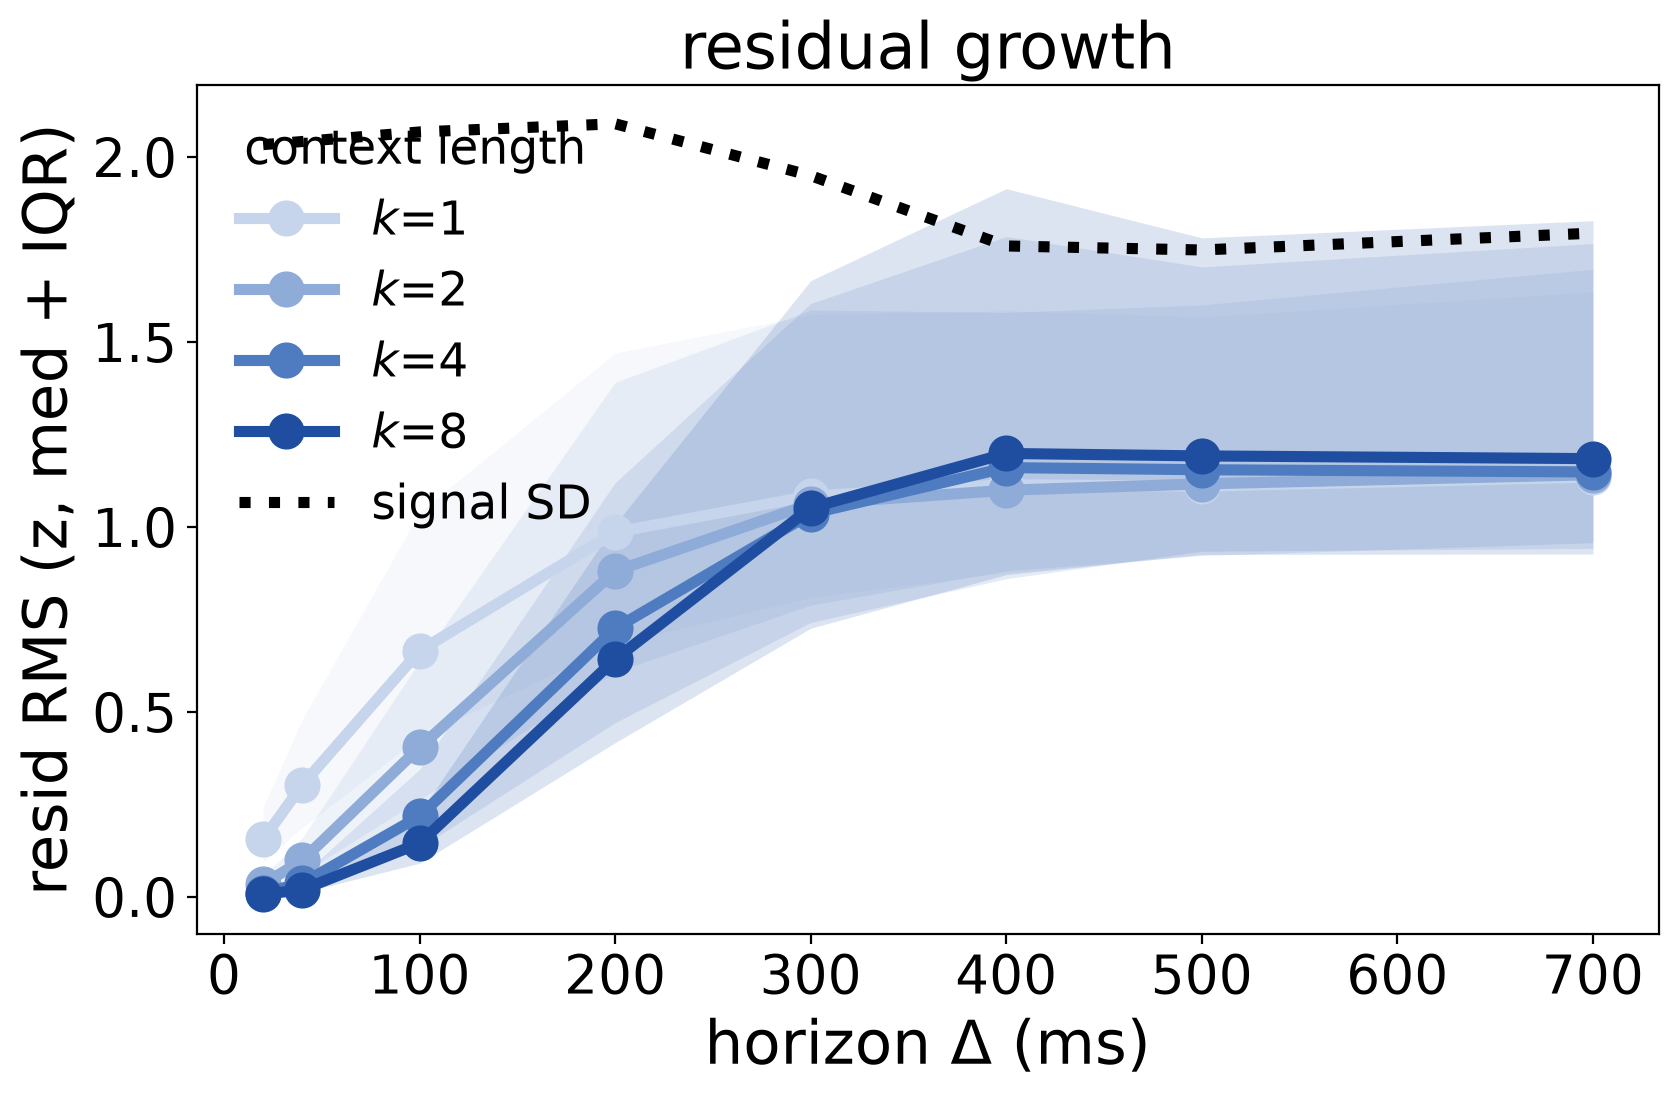

In [6]:
# ---------- Panel E: residual growth vs horizon for increasing context length ----------
ks_E = [1, 2, 4, 8]                    # 20 / 40 / 80 / 160 ms of history
h_E = [20, 40, 100, 200, 300, 400, 500, 700]
shades_E = ["#c6d4ec", "#8fabd8", "#4f7cc0", COLOR_LINEAR]
rows_E, sig_sd_E = [], {}
for k_ctx in ks_E:
    for h_ms in h_E:
        hsE = h_ms // TOKEN_STRIDE_MS
        XtE, YtE = make_pairs_ctx(z_r[tr], hsE, k_ctx)
        XvE, YvE = make_pairs_ctx(z_r[va], hsE, k_ctx)
        XiE, YiE = make_pairs_ctx(z_r[te], hsE, k_ctx)
        A_E, b_E, _ = fit_ridge(XtE, YtE, XvE, YvE)
        rn = resid_norms(YiE, ridge_predict(A_E, b_E, XiE))
        rows_E.append(dict(k_ctx=k_ctx, horizon_ms=h_ms,
                           med=float(np.median(rn)),
                           q25=float(np.percentile(rn, 25)),
                           q75=float(np.percentile(rn, 75))))
        if k_ctx == 1:
            sig_sd_E[h_ms] = float(YiE.std())    # saturation level: test-signal SD
panelE = pd.DataFrame(rows_E)
panelE.to_csv(RESULTS_DIR / "final_panelE_context_length_LVF_theta.csv", index=False)
display(panelE.pivot(index="horizon_ms", columns="k_ctx", values="med").round(3))

fig, axE = plt.subplots(figsize=(8.5, 5.6))
for k_ctx, colE in zip(ks_E, shades_E):
    sub_E = panelE[panelE.k_ctx == k_ctx].set_index("horizon_ms").sort_index()
    axE.fill_between(sub_E.index, sub_E.q25, sub_E.q75, color=colE, alpha=0.15, lw=0)
    axE.plot(sub_E.index, sub_E.med, "o-", color=colE, lw=4, ms=12, label=f"$k$={k_ctx}")
axE.plot(h_E, [sig_sd_E[h] for h in h_E], ":", color="black", lw=4, label="signal SD")
axE.set_xlabel("horizon $\\Delta$ (ms)", fontsize=22)
axE.set_ylabel("resid RMS (z, med + IQR)", fontsize=22)
axE.tick_params(labelsize=19)
axE.legend(fontsize=17, frameon=False, title="context length", title_fontsize=17)
axE.set_title("residual growth", fontsize=23)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR / f"final_panelE_context_length_P12_LVF_theta.{ext}", dpi=200, bbox_inches="tight")
print("saved ->", FIG_DIR / "final_panelE_context_length_P12_LVF_theta.png")
plt.close(fig)
display(IPyImage(str(FIG_DIR / "final_panelE_context_length_P12_LVF_theta.png"), width=280))

**Panel E — residual growth vs horizon, by context length.** Median (± IQR) per-token residual RMS of linear models conditioned on $k$ = 1–8 past tokens. Longer context suppresses short-horizon error by over an order of magnitude (0.16 → 0.007 z at Δ = 20 ms) but all curves converge to the signal SD (dotted) by Δ ≈ 300 ms, beyond which more context slightly *increases* error: context buys precision, not predictability horizon.

saved -> /home/dev/controller/code/figs/figure_brain/empirical/plots/final_panelF_state_size_P12_theta.png


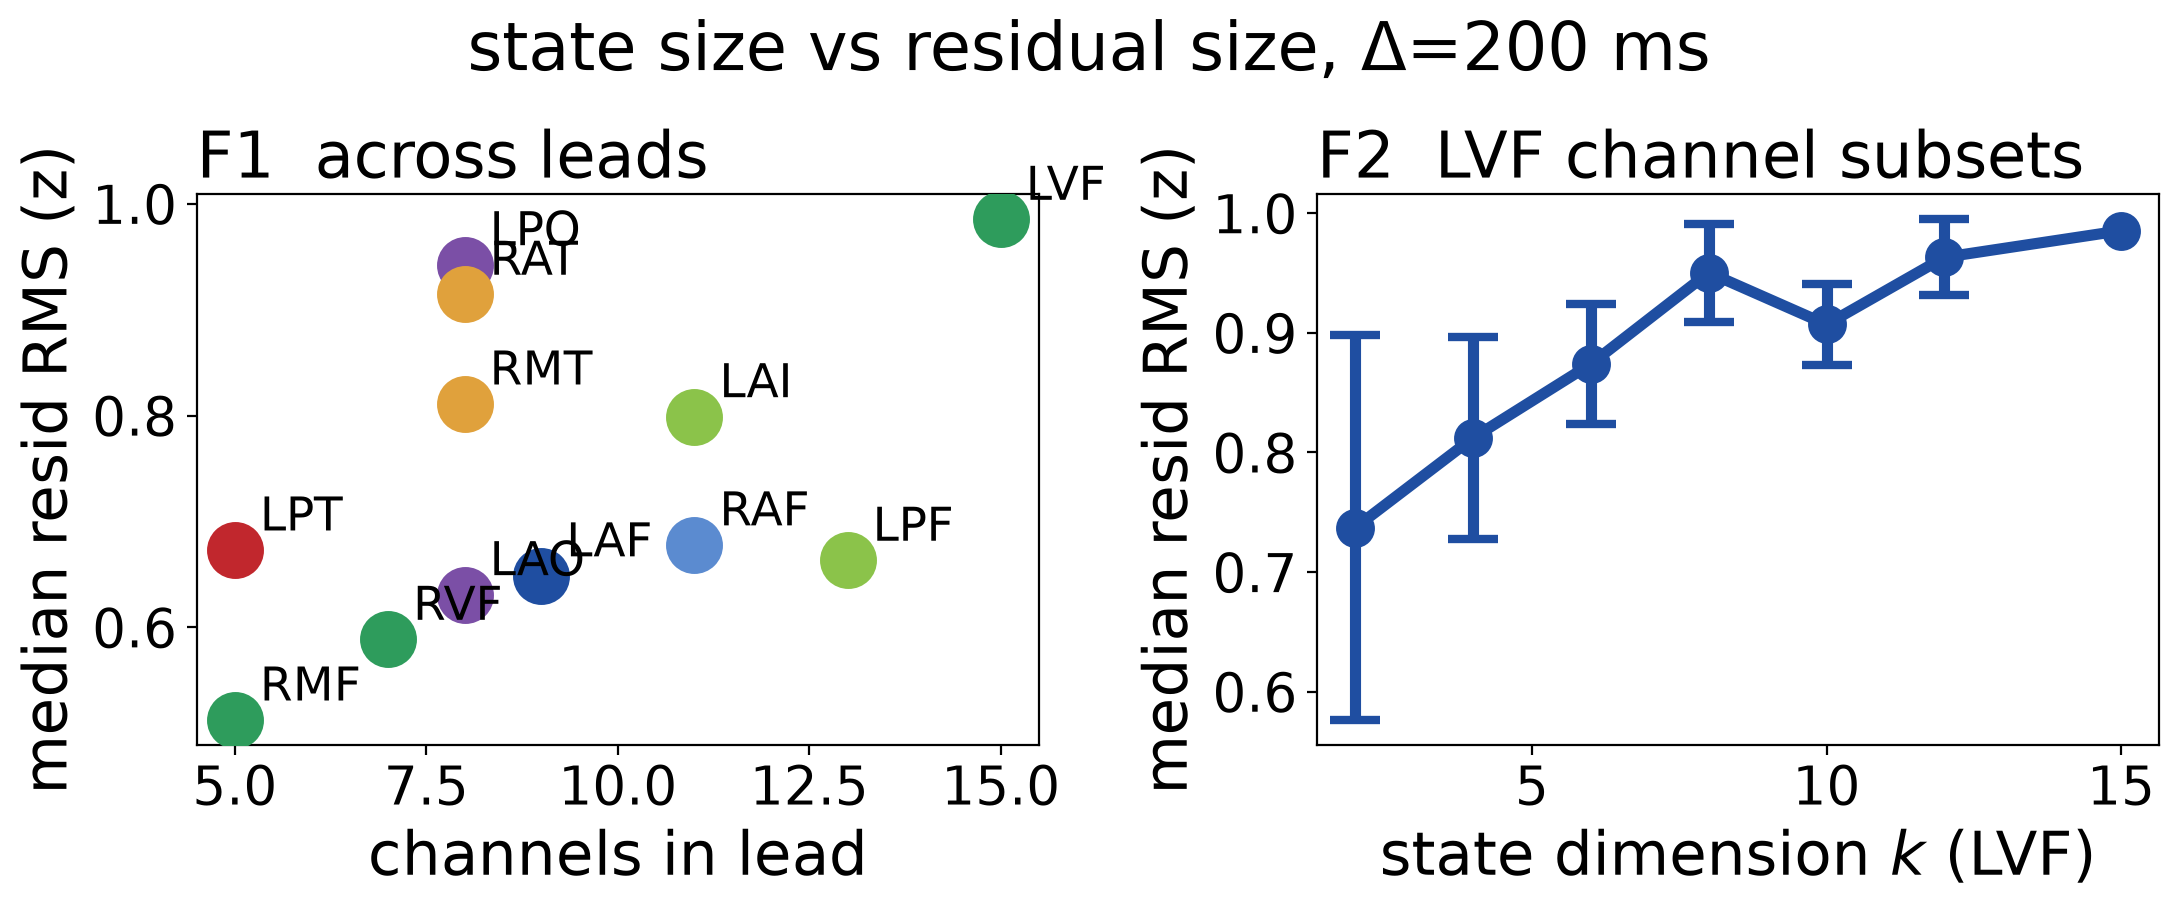

In [7]:
# ---------- Panel F: state size vs residual size (Δ = 200 ms) ----------
# F1 (observational): per-lead median residual RMS vs channel count across the montage.
# F2 (causal): random channel subsets WITHIN the LVF lead, refit and test.
h_ms_F = 200; hsF = h_ms_F // TOKEN_STRIDE_MS

# anatomy: coarse area per lead from mean MNI midpoint (parc4-6), for point colors
def coarse_area(x, y, z):
    if y <= -60:            return "parieto-occipital"
    if y <= -35 and z < 25: return "posterior temporal"
    if z < 20:              return "temporal / peri-insular"
    if z >= 40 and y >= 10: return "dorsolateral prefrontal"
    if y >= 10:             return "ventrolateral prefrontal"
    if y <= -12:            return "sensorimotor"
    return "premotor / dorsomedial frontal"

chdf = sess["channels"]
coords_ok = chdf[["parc4", "parc5", "parc6"]].notna().all(axis=1)
lead_stats = chdf[coords_ok].groupby("lead").agg(x=("parc4", "mean"), y=("parc5", "mean"), z=("parc6", "mean"))
lead_area = {ld: coarse_area(r.x, r.y, r.z) for ld, r in lead_stats.iterrows()}
AREA_ORDER = ["dorsolateral prefrontal", "ventrolateral prefrontal", "premotor / dorsomedial frontal",
              "sensorimotor", "temporal / peri-insular", "posterior temporal", "parieto-occipital"]
AREA_COLORS = dict(zip(AREA_ORDER, ["#1f4ea1", "#5b8bd0", "#2e9c5c", "#8bc34a", "#e0a13c", "#c1272d", "#7b4fa6"]))

# F1: per-lead frozen linear model, ID test residuals
rows_F1 = []
for lead_ in sorted(set(lead_clean)):
    cols_ns2 = np.flatnonzero((lead_clean == lead_) & matched)
    if len(cols_ns2) < MIN_CH:
        continue
    mu_l = baseline[tr][:, cols_ns2].mean(axis=0)
    sd_l = baseline[tr][:, cols_ns2].std(axis=0) + 1e-12
    z_id = (tokens[:, :, cols_ns2] - mu_l) / sd_l
    Xt_, Yt_ = make_pairs(z_id[tr], hsF)
    Xv_, Yv_ = make_pairs(z_id[va], hsF)
    Xi_, Yi_ = make_pairs(z_id[te], hsF)
    A_, b_, _ = fit_ridge(Xt_, Yt_, Xv_, Yv_)
    rows_F1.append(dict(lead=lead_, area=lead_area[lead_], n_ch=len(cols_ns2),
                        med_resid=float(np.median(resid_norms(Yi_, ridge_predict(A_, b_, Xi_))))))
f1 = pd.DataFrame(rows_F1)

# F2: channel subsampling within LVF
rng_F = np.random.default_rng(RANDOM_SEED)
n_full = z_r.shape[-1]
ks_F2 = [2, 4, 6, 8, 10, 12, n_full]
rows_F2 = []
for k in ks_F2:
    for rep in range(1 if k == n_full else 10):
        cols = np.sort(rng_F.choice(n_full, size=k, replace=False))
        zk = z_r[:, :, cols]
        XtF, YtF = make_pairs(zk[tr], hsF)
        XvF, YvF = make_pairs(zk[va], hsF)
        XiF, YiF = make_pairs(zk[te], hsF)
        A_F, b_F, _ = fit_ridge(XtF, YtF, XvF, YvF)
        rows_F2.append(dict(k=k, med_resid=float(np.median(resid_norms(YiF, ridge_predict(A_F, b_F, XiF))))))
f2 = pd.DataFrame(rows_F2).groupby("k")["med_resid"].agg(["mean", "std"])
pd.concat([f1.set_index("lead"), f2], axis=0).to_csv(RESULTS_DIR / "final_panelF_state_size_theta.csv")

fig, (axF1, axF2) = plt.subplots(1, 2, figsize=(11, 4.6))
for _, r_ in f1.iterrows():
    axF1.scatter(r_.n_ch, r_.med_resid, s=380, color=AREA_COLORS[r_.area], zorder=3)
    axF1.annotate(r_.lead, (r_.n_ch, r_.med_resid), fontsize=17, xytext=(9, 7),
                  textcoords="offset points")
axF1.set_xlabel("channels in lead", fontsize=22)
axF1.set_ylabel("median resid RMS (z)", fontsize=22)
axF1.set_title("F1  across leads", loc="left", fontsize=23)
axF2.errorbar(f2.index, f2["mean"], yerr=f2["std"], fmt="o-", color=COLOR_LINEAR,
              capsize=9, lw=4, ms=13, capthick=3)
axF2.set_xlabel("state dimension $k$ (LVF)", fontsize=22)
axF2.set_ylabel("median resid RMS (z)", fontsize=22)
axF2.set_title("F2  LVF channel subsets", loc="left", fontsize=23)
for ax_ in (axF1, axF2):
    ax_.tick_params(labelsize=19)
fig.suptitle(f"state size vs residual size, $\\Delta$={h_ms_F} ms", fontsize=24)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR / f"final_panelF_state_size_P12_theta.{ext}", dpi=200, bbox_inches="tight")
print("saved ->", FIG_DIR / "final_panelF_state_size_P12_theta.png")
plt.close(fig)
display(IPyImage(str(FIG_DIR / "final_panelF_state_size_P12_theta.png"), width=367))

**Panel F — state size vs residual size (Δ = 200 ms).** **F1:** per-lead median residual RMS vs channel count (color = coarse anatomical area). **F2:** random channel subsets within LVF. Absolute residuals grow with state dimension (0.74 → 0.99 z, k = 2 → 15) because larger channel sets carry more signal variance, but the growth decelerates toward the full lead; the variance-normalized accuracy (R²) is flat in k, so linearization *quality* is size-independent. Error bars shrink with k as subset-to-subset variability averages out.